# 06 — Model Inspection for Lane Head Integration

**Goal:** Inspect the YOLO26 architecture in detail to guide lane head integration design.

This notebook:
1. Prints a complete layer-by-layer breakdown (index, class, from, params, channels, H x W)
2. Runs a dummy forward pass to get actual tensor shapes at each layer
3. Dynamically identifies backbone/neck boundary
4. Shows detect head details (nc, nl, stride, reg_max)
5. Prints concrete recommendations for transformer lane head integration

## 1 — Setup

In [1]:
!pip install -q ultralytics>=8.4.0

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import torch
import torch.nn as nn
import numpy as np

ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
WEIGHTS = os.path.join(ECOCAR_ROOT, "weights", "bdd100k_yolo26s_best.pt")

# Fallback to pretrained if trained weights not available
USE_PRETRAINED = not os.path.isfile(WEIGHTS)
if USE_PRETRAINED:
    WEIGHTS = "yolo26s.pt"
    print("Trained weights not found. Using COCO-pretrained for inspection.")
    print("(Architecture is identical; only class count differs.)")
else:
    print(f"Using trained weights: {WEIGHTS}")

IMG_SIZE = 640  # standard input size for dummy forward pass

Using trained weights: /content/drive/MyDrive/EcoCAR/weights/bdd100k_yolo26s_best.pt


In [4]:
from ultralytics import YOLO

model = YOLO(WEIGHTS)
inner = model.model  # The nn.Module

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2 — Model Summary

In [5]:
num_layers = len(inner.model)
total_params = sum(p.numel() for p in inner.parameters())
trainable_params = sum(p.numel() for p in inner.parameters() if p.requires_grad)

print("=" * 60)
print(" YOLO26 MODEL SUMMARY")
print("=" * 60)
print(f" Task:              {model.task}")
print(f" Classes:           {len(model.names)}")
print(f" Total parameters:  {total_params:,}")
print(f" Trainable params:  {trainable_params:,}")
print(f" Top-level layers:  {num_layers}")
print(f" Weights file:      {WEIGHTS}")
print("=" * 60)

 YOLO26 MODEL SUMMARY
 Task:              detect
 Classes:           10
 Total parameters:  9,955,604
 Trainable params:  0
 Top-level layers:  24
 Weights file:      /content/drive/MyDrive/EcoCAR/weights/bdd100k_yolo26s_best.pt


## 3 — Dummy Forward Pass for Actual Tensor Shapes

In [6]:
# Register hooks on every layer to capture output shapes during a dummy forward pass
from collections import OrderedDict

layer_shapes = OrderedDict()
hooks = []

def make_hook(idx):
    def hook_fn(module, inp, out):
        if isinstance(out, torch.Tensor):
            layer_shapes[idx] = tuple(out.shape)
        elif isinstance(out, (list, tuple)):
            # Detect head returns a list — record shape of first tensor
            for item in out:
                if isinstance(item, torch.Tensor):
                    layer_shapes[idx] = tuple(item.shape)
                    break
            else:
                layer_shapes[idx] = f"list[{len(out)}]"
    return hook_fn

for idx in range(num_layers):
    h = inner.model[idx].register_forward_hook(make_hook(idx))
    hooks.append(h)

# Dummy forward pass
device = next(inner.parameters()).device
dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
with torch.no_grad():
    _ = inner(dummy)

# Remove hooks
for h in hooks:
    h.remove()

print(f"Captured shapes for {len(layer_shapes)} layers (input: 1x3x{IMG_SIZE}x{IMG_SIZE})")

Captured shapes for 24 layers (input: 1x3x640x640)


## 4 — Complete Layer-by-Layer Breakdown

In [7]:
# Dynamically identify backbone/neck boundary: first Concat or Upsample layer
detect_keywords = {'Detect', 'Segment', 'Classify', 'OBB', 'Pose', 'WorldDetect', 'E2EDetect'}

neck_start_idx = num_layers
for idx in range(num_layers):
    cls = inner.model[idx].__class__.__name__
    if cls in ('Concat', 'Upsample'):
        neck_start_idx = idx
        break

detect_idx = None
for idx in range(num_layers):
    if inner.model[idx].__class__.__name__ in detect_keywords or 'Detect' in inner.model[idx].__class__.__name__:
        detect_idx = idx
        break

print(f"Backbone:  layers 0..{neck_start_idx - 1}")
print(f"Neck:      layers {neck_start_idx}..{detect_idx - 1 if detect_idx else '?'}")
print(f"Head:      layer  {detect_idx}")
print()

header = f"{'Idx':>4} {'Class':<28} {'From':>6} {'Params':>12} {'Out Ch':>7} {'HxW':>10} {'Stride':>7} {'Region'}"
print(header)
print("-" * len(header))

# Collect layers into lists for later use
backbone_layers = []
neck_layers = []
head_layers = []

for idx in range(num_layers):
    layer = inner.model[idx]
    cls_name = layer.__class__.__name__
    params = sum(p.numel() for p in layer.parameters())

    # 'from' attribute (which layer feeds this one)
    f_attr = getattr(layer, 'f', '-')

    # Output shape info from dummy forward pass
    shape = layer_shapes.get(idx)
    if isinstance(shape, tuple) and len(shape) == 4:
        _, C, H, W = shape
        ch_str = str(C)
        hw_str = f"{H}x{W}"
        stride_str = str(IMG_SIZE // H)
    else:
        ch_str = '-'
        hw_str = str(shape) if shape else '-'
        stride_str = '-'

    # Region
    if cls_name in detect_keywords or 'Detect' in cls_name:
        region = "HEAD"
        head_layers.append((idx, cls_name, params))
    elif idx < neck_start_idx:
        region = "BACKBONE"
        backbone_layers.append((idx, cls_name, params))
    else:
        region = "NECK"
        neck_layers.append((idx, cls_name, params))

    print(
        f"  {idx:>2}  {cls_name:<28} {str(f_attr):>6} {params:>12,} {ch_str:>7} {hw_str:>10} {stride_str:>7}  {region}"
    )

print(f"\nCollected: {len(backbone_layers)} backbone, {len(neck_layers)} neck, {len(head_layers)} head layers")

Backbone:  layers 0..10
Neck:      layers 11..22
Head:      layer  23

 Idx Class                          From       Params  Out Ch        HxW  Stride Region
---------------------------------------------------------------------------------------
   0  Conv                             -1          928      32    320x320       2  BACKBONE
   1  Conv                             -1       18,560      64    160x160       4  BACKBONE
   2  C3k2                             -1       26,080     128    160x160       4  BACKBONE
   3  Conv                             -1      147,712     128      80x80       8  BACKBONE
   4  C3k2                             -1      103,360     256      80x80       8  BACKBONE
   5  Conv                             -1      590,336     256      40x40      16  BACKBONE
   6  C3k2                             -1      346,112     256      40x40      16  BACKBONE
   7  Conv                             -1    1,180,672     512      20x20      32  BACKBONE
   8  C3k2       

## 5 — Detailed Module Tree (3 levels)

In [8]:
print("Detailed module tree (first 3 levels):")
print("=" * 70)

for name, module in inner.named_modules():
    depth = name.count('.')
    if depth > 3:
        continue
    indent = "  " * depth
    params = sum(p.numel() for p in module.parameters(recurse=False))
    cls_name = module.__class__.__name__
    param_str = f" ({params:,} params)" if params > 0 else ""
    print(f"{indent}|- {name or 'root'}: {cls_name}{param_str}")

Detailed module tree (first 3 levels):
|- root: DetectionModel
|- model: Sequential
  |- model.0: Conv
    |- model.0.conv: Conv2d (864 params)
    |- model.0.bn: BatchNorm2d (64 params)
    |- model.0.act: SiLU
  |- model.1: Conv
    |- model.1.conv: Conv2d (18,432 params)
    |- model.1.bn: BatchNorm2d (128 params)
  |- model.2: C3k2
    |- model.2.cv1: Conv
      |- model.2.cv1.conv: Conv2d (4,096 params)
      |- model.2.cv1.bn: BatchNorm2d (128 params)
    |- model.2.cv2: Conv
      |- model.2.cv2.conv: Conv2d (12,288 params)
      |- model.2.cv2.bn: BatchNorm2d (256 params)
    |- model.2.m: ModuleList
      |- model.2.m.0: Bottleneck
  |- model.3: Conv
    |- model.3.conv: Conv2d (147,456 params)
    |- model.3.bn: BatchNorm2d (256 params)
  |- model.4: C3k2
    |- model.4.cv1: Conv
      |- model.4.cv1.conv: Conv2d (16,384 params)
      |- model.4.cv1.bn: BatchNorm2d (256 params)
    |- model.4.cv2: Conv
      |- model.4.cv2.conv: Conv2d (49,152 params)
      |- model.4.cv2.bn:

## 6 — Parameter Distribution

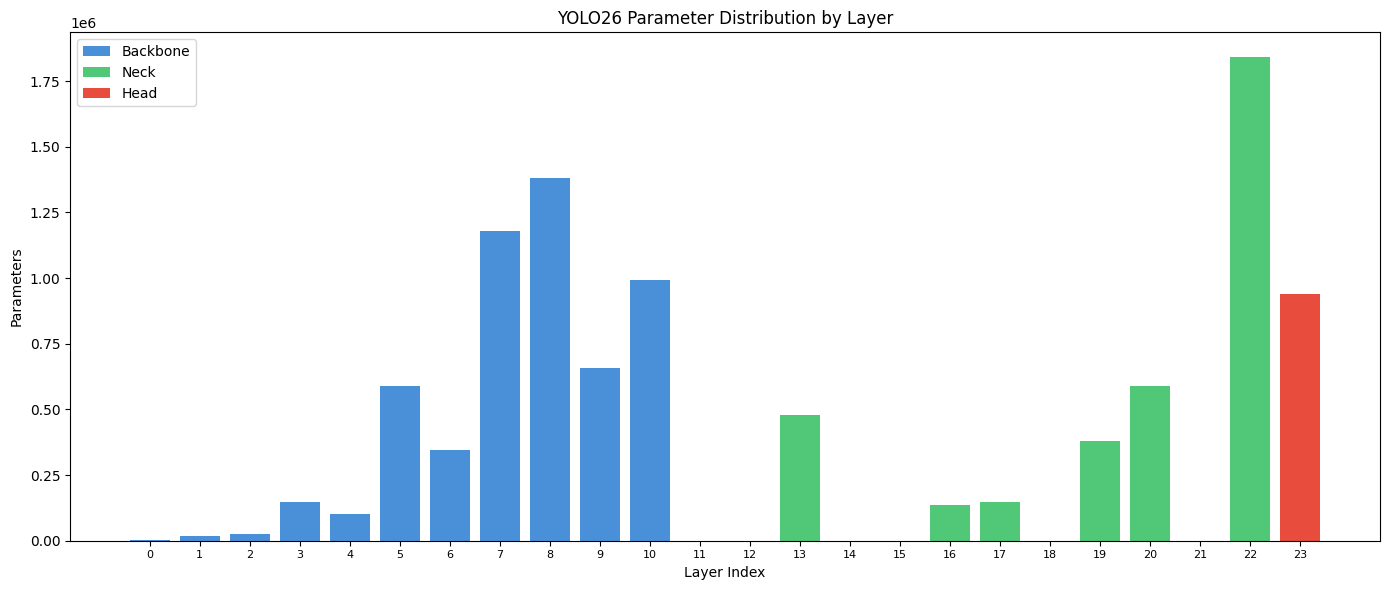

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

layer_params = []
layer_colors = []

for idx in range(num_layers):
    layer = inner.model[idx]
    params = sum(p.numel() for p in layer.parameters())
    layer_params.append(params)

    cls_name = layer.__class__.__name__
    if cls_name in detect_keywords or 'Detect' in cls_name:
        layer_colors.append('#E74C3C')  # red = head
    elif idx < neck_start_idx:
        layer_colors.append('#4A90D9')  # blue = backbone
    else:
        layer_colors.append('#50C878')  # green = neck

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(layer_params)), layer_params, color=layer_colors)
ax.set_xlabel('Layer Index')
ax.set_ylabel('Parameters')
ax.set_title('YOLO26 Parameter Distribution by Layer')
ax.set_xticks(range(len(layer_params)))
ax.set_xticklabels([str(i) for i in range(len(layer_params))], fontsize=8)

legend_elements = [
    Patch(facecolor='#4A90D9', label='Backbone'),
    Patch(facecolor='#50C878', label='Neck'),
    Patch(facecolor='#E74C3C', label='Head'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

## 7 — Detection Head Details

In [10]:
if detect_idx is not None:
    head = inner.model[detect_idx]

    print(f"Detection Head (layer [{detect_idx}]):")
    print(f"  Type:   {head.__class__.__name__}")
    print(f"  Params: {sum(p.numel() for p in head.parameters()):,}")

    # Key attributes
    for attr in ('nc', 'nl', 'no', 'reg_max'):
        if hasattr(head, attr):
            print(f"  {attr:>8}: {getattr(head, attr)}")

    # Stride
    if hasattr(head, 'stride'):
        stride_vals = head.stride
        if isinstance(stride_vals, torch.Tensor):
            stride_vals = stride_vals.tolist()
        print(f"  stride:  {stride_vals}")

    # Input channels to the head (from attribute 'f' or 'ch')
    if hasattr(head, 'ch'):
        print(f"  Input ch per scale: {head.ch}")

    # Submodules
    print(f"\n  Submodules:")
    for name, mod in head.named_modules():
        if name and name.count('.') < 2:
            params = sum(p.numel() for p in mod.parameters(recurse=False))
            print(f"    {name}: {mod.__class__.__name__} ({params:,} params)")
else:
    print("No detection head found.")

Detection Head (layer [23]):
  Type:   Detect
  Params: 939,604
        nc: 10
        nl: 3
        no: 14
   reg_max: 1
  stride:  [8.0, 16.0, 32.0]

  Submodules:
    cv2: ModuleList (0 params)
    cv2.0: Sequential (0 params)
    cv2.1: Sequential (0 params)
    cv2.2: Sequential (0 params)
    cv3: ModuleList (0 params)
    cv3.0: Sequential (0 params)
    cv3.1: Sequential (0 params)
    cv3.2: Sequential (0 params)
    dfl: Identity (0 params)
    one2one_cv2: ModuleList (0 params)
    one2one_cv2.0: Sequential (0 params)
    one2one_cv2.1: Sequential (0 params)
    one2one_cv2.2: Sequential (0 params)
    one2one_cv3: ModuleList (0 params)
    one2one_cv3.0: Sequential (0 params)
    one2one_cv3.1: Sequential (0 params)
    one2one_cv3.2: Sequential (0 params)


## 8 — Guidance for Future Lane Marking Integration

### Which features to use for lane marking?

| Feature Source | Resolution | Best For |
|---|---|---|
| **Early backbone** (layers 0-3) | High res, low semantic | Edge/texture detection |
| **Mid backbone** (layers 4-6) | Medium | Shape features |
| **Late backbone** (layers 7-9) | Low res, high semantic | Semantic understanding |
| **Neck features** | Multi-scale | Best overall — fused features |

### Recommended approach:
1. **Hook into neck layers** for multi-scale feature maps
2. **Feed into a lightweight lane decoder** (e.g., simple conv + upsampling head)
3. **Freeze backbone + neck** initially, train only the lane decoder
4. **Fine-tune end-to-end** once the lane head converges

### Key layer indices for lane features:
Use the component identification above to find the exact indices for your model variant.

In [11]:
# Print a quick reference of recommended hook points
print("\n" + "="*60)
print(" RECOMMENDED FEATURE EXTRACTION POINTS")
print("="*60)

if backbone_layers:
    mid = len(backbone_layers) // 2
    print(f"\n  Backbone (for feature extractor):")
    print(f"    Early: layer [{backbone_layers[0][0]}] ({backbone_layers[0][1]})")
    print(f"    Mid:   layer [{backbone_layers[mid][0]}] ({backbone_layers[mid][1]})")
    print(f"    Late:  layer [{backbone_layers[-1][0]}] ({backbone_layers[-1][1]})")

if neck_layers:
    print(f"\n  Neck (for multi-scale features):")
    for idx, cls_name, params in neck_layers:
        if params > 0:  # Skip Upsample/Concat with no params
            print(f"    layer [{idx}] ({cls_name}, {params:,} params)")

print(f"\n  Detection head:")
for idx, cls_name, params in head_layers:
    print(f"    layer [{idx}] ({cls_name}, {params:,} params)")

print("\n" + "="*60)
print("\n📌 Use notebook 05 to extract features from these layers.")
print("   The FeatureExtractor class accepts layer_indices directly.")


 RECOMMENDED FEATURE EXTRACTION POINTS

  Backbone (for feature extractor):
    Early: layer [0] (Conv)
    Mid:   layer [5] (Conv)
    Late:  layer [10] (C2PSA)

  Neck (for multi-scale features):
    layer [13] (C3k2, 477,184 params)
    layer [16] (C3k2, 136,192 params)
    layer [17] (Conv, 147,712 params)
    layer [19] (C3k2, 378,880 params)
    layer [20] (Conv, 590,336 params)
    layer [22] (C3k2, 1,843,712 params)

  Detection head:
    layer [23] (Detect, 939,604 params)


📌 Use notebook 05 to extract features from these layers.
   The FeatureExtractor class accepts layer_indices directly.


## 9 — Export Model Info to File

In [12]:
# Save architecture info for reference
info_path = os.path.join(ECOCAR_ROOT, "outputs", "model_architecture_info.txt")
os.makedirs(os.path.dirname(info_path), exist_ok=True)

with open(info_path, 'w') as f:
    f.write("YOLO26 Architecture Reference\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Weights: {WEIGHTS}\n")
    f.write(f"Task: {model.task}\n")
    f.write(f"Classes: {len(model.names)}\n")
    f.write(f"Total params: {total_params:,}\n")
    f.write(f"Total layers: {num_layers}\n\n")

    f.write("BACKBONE\n")
    for idx, cls_name, params in backbone_layers:
        f.write(f"  [{idx}] {cls_name} ({params:,})\n")

    f.write("\nNECK\n")
    for idx, cls_name, params in neck_layers:
        f.write(f"  [{idx}] {cls_name} ({params:,})\n")

    f.write("\nHEAD\n")
    for idx, cls_name, params in head_layers:
        f.write(f"  [{idx}] {cls_name} ({params:,})\n")

print(f"Architecture info saved: {info_path}")
print("\nModel inspection complete!")

Architecture info saved: /content/drive/MyDrive/EcoCAR/outputs/model_architecture_info.txt

Model inspection complete!
